# 02 — Description length, and a correction

*Confirmed results C15–C22. B4 answered twice, because the first answer was to the wrong question.*

Companion to `bitacora/04_b4_description_length.md` and `bitacora/05_phase1b_gate_network.md`.

In [1]:
"""Path setup: makes the notebook runnable from anywhere."""
import os, sys, json, warnings
warnings.filterwarnings("ignore")

here = os.path.abspath(os.getcwd())
while here != "/" and not os.path.exists(os.path.join(here, "PROTOCOL_causal_timeseries.md")):
    here = os.path.dirname(here)
if here == "/":
    here = os.path.expanduser("~/Documents/projects/CausalBool/imp-prices")
ROOT = here
sys.path.insert(0, os.path.join(ROOT, "src"))
sys.path.insert(0, os.path.join(ROOT, "scripts"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})
print("root:", ROOT)
print("numpy", np.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

root: /Users/alberto/Documents/projects/CausalBool/imp-prices
numpy 2.2.6 | pandas 2.3.3 | matplotlib 3.11.1


## 1. What this notebook establishes, including where it corrects itself

The question is B4: **does the index-set representation describe the same
relationship in fewer bits than a conditional probability table?**

It is answered twice, because the first answer was to the wrong question.

1. **Phase 1 (C15–C18).** A parent set plus an *arbitrary lookup table* against a
   conditional probability table. The table won. But an arbitrary lookup table is
   not the index-set method — it is the thing the method was invented to replace —
   and the instrument was a counting code, which is blind to structure by
   construction.
2. **Phase 1b (C19–C22).** The real seventeen-gate family from the validated
   forward model, a whole fourteen-node network, and BDM as the model term. The
   table won again, and the reason became much clearer.

Both are shown. The Phase 1 numbers are measurements of a degenerate encoding —
only their *label* was wrong — and deleting them would hide how the conclusion
was reached.

### 2. Why the comparison must be two-part

A description-length comparison is trivially riggable by choice of encoding, so
the shape of the comparison matters more than the numbers.

    L_total = L(model) + L(data | model)

Comparing model sizes alone is meaningless: a model of zero bits that predicts
nothing would win. Every code below is checked against **Kraft's inequality**
rather than asserted to be a code, and the conditional probability table is given
the *favourable* convention — Rissanen's optimal precision of ½log₂N bits per
free parameter, which is what the Bayesian information criterion assumes.

In [2]:
from imp_prices.index_set import (elias_gamma_bits, structure_bits, residual_bits,
                                  scan_codes, best_by_total, marginal_code,
                                  prequential_bits, bootstrap_parent_sets)
import math

kraft_int = sum(2.0 ** -elias_gamma_bits(n) for n in range(4096))
kraft_str = sum(math.comb(7, k) * 2.0 ** -structure_bits(7, k, 3) for k in range(4))
print(f"Kraft sum, integer code   : {kraft_int:.6f}  (must be <= 1)")
print(f"Kraft sum, parent-set code: {kraft_str:.6f}  (must be <= 1)")

print("\nResidual code: more errors must never cost fewer bits.")
for e in (0, 1, 5, 20, 60):
    print(f"   {e:3d} errors in 137 months -> {residual_bits(137, e, 3):8.2f} bits")

Kraft sum, integer code   : 0.999756  (must be <= 1)
Kraft sum, parent-set code: 1.000000  (must be <= 1)

Residual code: more errors must never cost fewer bits.
     0 errors in 137 months ->     1.00 bits
     1 errors in 137 months ->    11.10 bits
     5 errors in 137 months ->    38.48 bits
    20 errors in 137 months ->   107.78 bits
    60 errors in 137 months ->   202.61 bits


### 3. The cost gap that made Phase 1 the wrong test

This single comparison is the whole of the assessor's objection. An arbitrary map
over three inputs must transmit one symbol per realised pattern. A *named* gate
transmits only its name.

In [3]:
from imp_prices.gate_network import gate_catalogue
for k in (1, 2, 3):
    cat = gate_catalogue(k)
    named_bits = math.log2(len(cat) + 2)
    map_bits_ternary = (3 ** k) * math.log2(3)
    lut_bits_binary = 2 ** k
    print(f"in-degree {k}:  named gate {named_bits:5.2f} bits  |  "
          f"binary LUT {lut_bits_binary:5.2f}  |  ternary arbitrary map {map_bits_ternary:6.2f}"
          f"   -> map/gate = {map_bits_ternary / named_bits:5.1f}x")
print("\nPhase 1 charged the ternary-map price and called the result a defeat of the method.")
print("Most of the 15.56-bit gap it reported was this accounting choice.")

in-degree 1:  named gate  4.17 bits  |  binary LUT  2.00  |  ternary arbitrary map   4.75   -> map/gate =   1.1x
in-degree 2:  named gate  4.75 bits  |  binary LUT  4.00  |  ternary arbitrary map  14.26   -> map/gate =   3.0x
in-degree 3:  named gate  5.17 bits  |  binary LUT  8.00  |  ternary arbitrary map  42.79   -> map/gate =   8.3x

Phase 1 charged the ternary-map price and called the result a defeat of the method.
Most of the 15.56-bit gap it reported was this accounting choice.


### 4. Phase 1 as it stands: controls, then the verdict (C15–C17)

In [4]:
from imp_prices import RegimeDiscretiser, SERIES, TARGET, load_and_split
from imp_prices.controls import random_frame, rule110_frame

split = load_and_split()
frame = RegimeDiscretiser("gaussian").fit(split.train).transform(split.full)
train = frame.reindex(split.train.index).dropna().astype(int)

rows = []
for label, fr, tgt, cols, alpha in [
        ("rule 110 (deterministic)", rule110_frame(7, 200), "c0", None, 2),
        ("random ternary", random_frame(7, 200, 3), "c0", None, 3),
        ("the panel", train, TARGET, SERIES, 3)]:
    cols = cols or list(fr.columns)
    tab = scan_codes(fr, tgt, cols, 3, alpha)
    marg = tab[tab["k"] == 0].iloc[0]["total_bits"]
    isb = best_by_total(tab[tab["k"] > 0], "index-set")
    cpt = best_by_total(tab[tab["k"] > 0], "cpt")
    rows.append(dict(case=label, marginal=round(marg, 2),
                     index_set=round(isb["total_bits"], 2),
                     cpt=round(cpt["total_bits"], 2),
                     difference=round(isb["total_bits"] - cpt["total_bits"], 2),
                     IS_beats_marginal=isb["total_bits"] < marg,
                     CPT_beats_marginal=cpt["total_bits"] < marg))
display(pd.DataFrame(rows).set_index("case"))
print("Controls: on rule 110 the index-set code wins decisively and pays ~0 for data.")
print("On noise NEITHER beats the marginal -> the accounting is not biased in our favour.")
print("On the panel the CPT wins by 15.56 bits, and BOTH beat the marginal, so the")
print("panel is not empty: it holds the persistence of C8, better captured probabilistically.")

Model is not converging.  Current: 133.6292135815284 is not greater than 133.64611090460522. Delta is -0.016897323076818793


Model is not converging.  Current: 135.12412379396633 is not greater than 135.13466135759776. Delta is -0.010537563631430658


Model is not converging.  Current: 137.95241214051376 is not greater than 137.9719991672316. Delta is -0.019587026717829303


Model is not converging.  Current: 133.8785930254865 is not greater than 133.88411470889034. Delta is -0.0055216834038276374


Model is not converging.  Current: 137.8805787609427 is not greater than 137.88701219673231. Delta is -0.0064334357896029815


...

Model is not converging.  Current: 138.689566784798 is not greater than 138.75651219277114. Delta is -0.06694540797315085


Model is not converging.  Current: 137.73058048980627 is not greater than 137.74346014343874. Delta is -0.012879653632467125


Model is not converging.  Current: 137.0533835102066 is not greater than 137.05519354805233. Delta is -0.0018100378457290844


,marginal,index_set,cpt,difference,IS_beats_marginal,CPT_beats_marginal
case,,,,,,
rule 110 (deterministic),200.85,16.13,48.46,-32.33,True,True
random ternary,321.03,325.82,330.61,-4.79,False,False
the panel,178.14,153.63,138.07,15.56,True,True


Controls: on rule 110 the index-set code wins decisively and pays ~0 for data.
On noise NEITHER beats the marginal -> the accounting is not biased in our favour.
On the panel the CPT wins by 15.56 bits, and BOTH beat the marginal, so the
panel is not empty: it holds the persistence of C8, better captured probabilistically.


#### The obvious objection — does it rest on the precision convention? (C16)

In [5]:
pre = [prequential_bits(train, TARGET, p, m)
       for p in ([], ["WTI_CL"]) for m in ("index-set", "cpt") if p or m == "cpt"]
display(pd.DataFrame(pre).set_index(["model", "parents"]))
print("The prequential code needs no precision convention anywhere: it encodes the")
print("column one symbol at a time, refitting on the prefix. It agrees.")

,,prequential_bits,n_scored,bits_per_observation
model,parents,,,
cpt,(none),162.87,125,1.3029
index-set,WTI_CL,134.90,125,1.0792
cpt,WTI_CL,116.50,125,0.9320


The prequential code needs no precision convention anywhere: it encodes the
column one symbol at a time, refitting on the prefix. It agrees.


#### And the stability result that contradicted my own argument (C18)

Bitácora 03 argued the index-set side could not suffer the belief network's
instability. That was labelled an argument rather than a measurement. The
measurement went the other way.

index-set   22 distinct winners / 200   modal Brent_BZ+Fed_Funds+WTI_Spot  24.5%
cpt          4 distinct winners / 200   modal WTI_CL                       51.0%


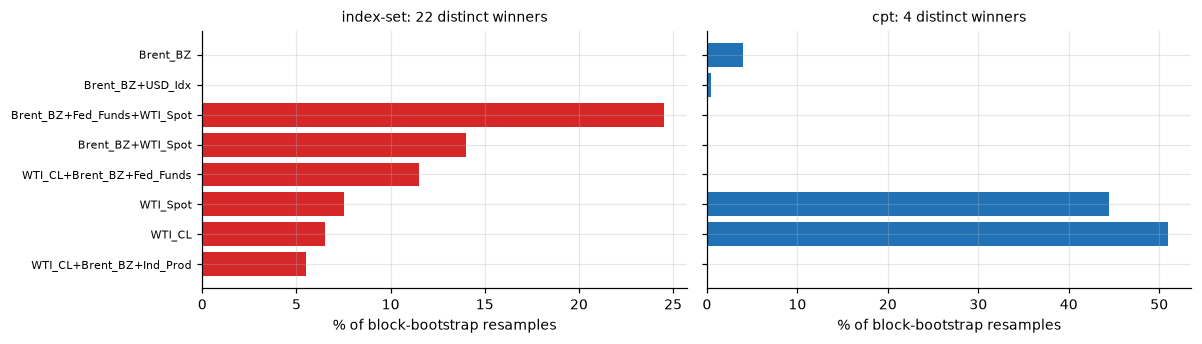

Resampling is by moving blocks of 12 months. An independent bootstrap would
destroy the persistence that dominates this target and flatter every selector.


In [6]:
boot = {s: bootstrap_parent_sets(train, TARGET, SERIES, 3, 3, n_boot=200,
                                 seed=42, block=12, scorer=s)
        for s in ("index-set", "cpt")}
for s, b in boot.items():
    print(f"{s:<10s} {b['n_distinct_winners']:3d} distinct winners / {b['n_boot']}   "
          f"modal {b['modal_parents']:<28s} {100 * b['modal_frequency']:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, (s, b) in zip(axes, boot.items()):
    top = b["top"][:6]
    ax.barh([r["parents"] for r in top][::-1], [100 * r["frequency"] for r in top][::-1],
            color="#2171B5" if s == "cpt" else "#D62728")
    ax.set_title(f"{s}: {b['n_distinct_winners']} distinct winners", fontsize=9)
    ax.set_xlabel("% of block-bootstrap resamples")
    ax.tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.show()
print("Resampling is by moving blocks of 12 months. An independent bootstrap would")
print("destroy the persistence that dominates this target and flatter every selector.")

### 5. The correction: the method as it actually is

Three changes, each answering a specific defect above. The gate catalogue is
*generated* by calling `apply_gate` from the vendored forward model — the same
code that achieves 200/200 exact recovery and is proven identical to
`CausalBoolCore.wl` — so it cannot drift from the semantics it represents.

In [7]:
from imp_prices.binarise import encode_frame, reachable_codes, round_trip_ok

for kind in ("thermometer", "binary", "onehot"):
    rc = reachable_codes(kind)
    print(f"{kind:<12s} {rc['mapping']}  width {rc['width']}  "
          f"unreachable codes {rc['n_unreachable']}  round-trip {round_trip_ok(train, kind)}")
print("\nThermometer is primary because the regimes are ORDERED: they are labelled by")
print("mean monthly log return, so bear < stagnant < bull is a fact about the fit.")
print("All three are reported whatever they show; best-of-three would be selection")
print("over encodings, which is the error Level 4 of the programme records.")

cat3 = {t for _, _, t in gate_catalogue(3)}
print(f"\nGate family covers {len(cat3)} of 256 arity-3 Boolean functions "
      f"({100 * len(cat3) / 256:.1f}%) -> it cannot fit anything (rule R4).")

thermometer  {0: '00', 1: '10', 2: '11'}  width 2  unreachable codes 1  round-trip True
binary       {0: '00', 1: '10', 2: '01'}  width 2  unreachable codes 1  round-trip True
onehot       {0: '100', 1: '010', 2: '001'}  width 3  unreachable codes 5  round-trip True

Thermometer is primary because the regimes are ORDERED: they are labelled by
mean monthly log return, so bear < stagnant < bull is a fact about the fit.
All three are reported whatever they show; best-of-three would be selection
over encodings, which is the error Level 4 of the programme records.

Gate family covers 17 of 256 arity-3 Boolean functions (6.6%) -> it cannot fit anything (rule R4).


#### BDM's resolution is enforced, not assumed

`imp-pathinfo` established that BDM can track object *size* rather than
structure. So the separation between structured and random arrays is measured at
every shape used, and a shape that fails is reported as unusable rather than used
anyway.

,constant,identity,random_mean,random_sd,separation_sigma,usable
shape,,,,,,
4x4,22.007,23.239,30.128,2.137,3.22,False
8x8,24.007,47.245,121.062,4.119,17.92,True
14x8,24.592,48.245,181.589,5.319,25.07,True
14x14,25.177,49.415,273.164,6.869,32.57,True


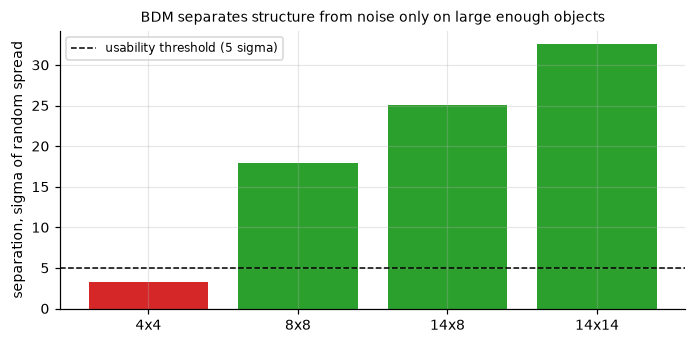

This is why the scored object is the WHOLE NETWORK (14x14) and not a single
node's table. A verdict drawn at 4x4 would be a verdict about size, not structure.


In [8]:
from imp_prices.algorithmic import resolution_check
res = pd.DataFrame([resolution_check(s) for s in [(4, 4), (8, 8), (14, 8), (14, 14)]])
res["shape"] = res["shape"].apply(lambda s: f"{s[0]}x{s[1]}")
display(res.set_index("shape")[["constant", "identity", "random_mean", "random_sd",
                                "separation_sigma", "usable"]])

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.bar(res["shape"], res["separation_sigma"], color=["#D62728" if not u else "#2CA02C"
                                                     for u in res["usable"]])
ax.axhline(5, ls="--", color="black", lw=1, label="usability threshold (5 sigma)")
ax.set_ylabel("separation, sigma of random spread"); ax.legend(fontsize=8)
ax.set_title("BDM separates structure from noise only on large enough objects", fontsize=9)
plt.tight_layout(); plt.show()
print("This is why the scored object is the WHOLE NETWORK (14x14) and not a single")
print("node's table. A verdict drawn at 4x4 would be a verdict about size, not structure.")

### 6. Phase 1b: the corrected comparison (C19, C21)

In [9]:
from imp_prices.gate_network import (fit_network, connectivity_matrix,
                                     truth_table_array, parameter_array)
from imp_prices.algorithmic import bdm_bits, structure_axis
from imp_prices.controls import rule110_frame

def score(fr, label):
    cols = list(fr.columns)
    g = fit_network(fr, cols, "gate", 3)
    c = fit_network(fr, cols, "cpt", 3)
    gt = (bdm_bits(connectivity_matrix(g, cols)) + bdm_bits(truth_table_array(g, 3))
          + sum(f.data_bits for f in g))
    ct = (bdm_bits(connectivity_matrix(c, cols)) + bdm_bits(parameter_array(c, 3))
          + sum(f.data_bits for f in c))
    named = {}
    for f in g:
        named[f.gate] = named.get(f.gate, 0) + 1
    return dict(case=label, gate_bits=round(gt, 1), cpt_bits=round(ct, 1),
                difference=round(gt - ct, 1), gate_wins=gt < ct,
                counting_gate=round(sum(f.total for f in g), 1),
                counting_cpt=round(sum(f.total for f in c), 1),
                errors=sum(f.n_errors for f in g),
                of=sum(f.n for f in g), gates=named), g, c

rows = []
ca = rule110_frame(width=14, steps=400)
r, ca_g, _ = score(ca, "rule 110 (deterministic network)"); rows.append(r)
rnd = pd.DataFrame(np.random.default_rng(42).integers(0, 2, size=(400, 14)),
                   columns=[f"c{i}" for i in range(14)])
r, _, _ = score(rnd, "random binary"); rows.append(r)
panel_fits = {}
for kind in ("thermometer", "binary", "onehot"):
    r, g, c = score(encode_frame(train, kind), f"panel / {kind}")
    rows.append(r); panel_fits[kind] = (g, c)

tab = pd.DataFrame(rows).set_index("case")
display(tab[["gate_bits", "cpt_bits", "difference", "gate_wins",
             "counting_gate", "counting_cpt", "errors", "of"]])
print("Controls both ways: rule 110 fitted with ZERO errors and a ~456-bit win;")
print("random binary LOSES at a ~46% error rate, which is chance.")
print("Panel: the CPT wins on all three binarisations, under BOTH instruments.")

,gate_bits,cpt_bits,difference,gate_wins,counting_gate,counting_cpt,errors,of
case,,,,,,,,
rule 110 (deterministic network),258.9,715.0,-456.0,True,273.1,722.5,0,5586
random binary,6039.4,5907.8,131.6,False,5795.9,5739.6,2587,5586
panel / thermometer,933.0,904.5,28.5,False,781.8,730.7,124,1918
panel / binary,977.9,959.2,18.7,False,808.3,766.5,134,1918
panel / onehot,1485.2,1471.9,13.3,False,1174.1,1118.6,198,2877


Controls both ways: rule 110 fitted with ZERO errors and a ~456-bit win;
random binary LOSES at a ~46% error rate, which is chance.
Panel: the CPT wins on all three binarisations, under BOTH instruments.


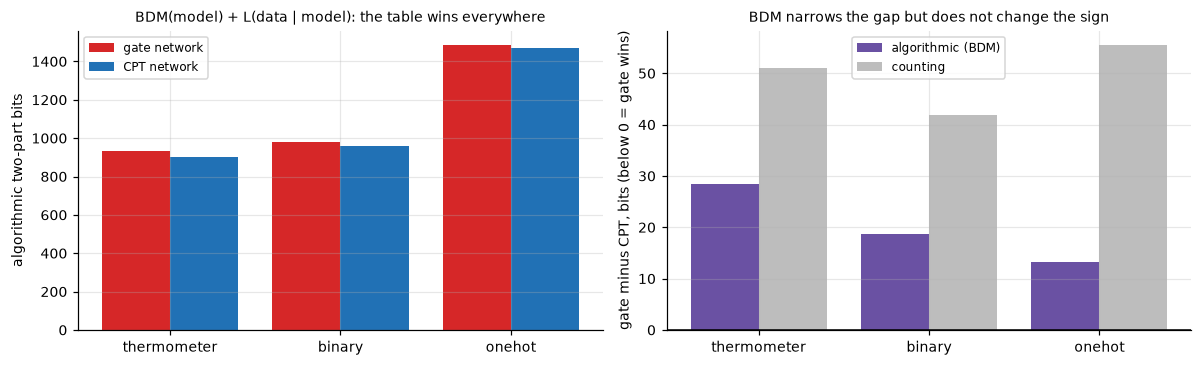

The objection about the instrument was right that BDM would change the number:
the primary gap falls from +51.1 bits (counting) to +28.5 (algorithmic).
It did not change the sign.


In [10]:
p = tab.loc[[i for i in tab.index if i.startswith("panel")]]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
x = np.arange(len(p)); labels = [i.split("/")[1].strip() for i in p.index]
axes[0].bar(x - 0.2, p["gate_bits"], 0.4, label="gate network", color="#D62728")
axes[0].bar(x + 0.2, p["cpt_bits"], 0.4, label="CPT network", color="#2171B5")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels); axes[0].legend(fontsize=8)
axes[0].set_ylabel("algorithmic two-part bits")
axes[0].set_title("BDM(model) + L(data | model): the table wins everywhere", fontsize=9)

alg = p["difference"].values
cnt = (p["counting_gate"] - p["counting_cpt"]).values
axes[1].bar(x - 0.2, alg, 0.4, label="algorithmic (BDM)", color="#6A51A3")
axes[1].bar(x + 0.2, cnt, 0.4, label="counting", color="#BDBDBD")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels); axes[1].legend(fontsize=8)
axes[1].set_ylabel("gate minus CPT, bits (below 0 = gate wins)")
axes[1].set_title("BDM narrows the gap but does not change the sign", fontsize=9)
plt.tight_layout(); plt.show()
print("The objection about the instrument was right that BDM would change the number:")
print(f"the primary gap falls from {cnt[0]:+.1f} bits (counting) to {alg[0]:+.1f} (algorithmic).")
print("It did not change the sign.")

### 7. The deepest finding: nothing here is gate-like (C20)

If the panel's conditionals were gate-shaped, the family would name them. The
family that names AND, XOR, MAJORITY, CANALISING and REGULATORY names almost
nothing.

In [11]:
rows = []
for kind, (g, c) in panel_fits.items():
    counts = {}
    for f in g:
        counts[f.gate] = counts.get(f.gate, 0) + 1
    named = sum(v for k, v in counts.items() if k != "LUT")
    rows.append(dict(binarisation=kind, nodes=len(g), named_gates=named,
                     LUT_fallbacks=counts.get("LUT", 0), detail=counts))
display(pd.DataFrame(rows).set_index("binarisation"))

ca_counts = {}
for f in ca_g:
    ca_counts[f.gate] = ca_counts.get(f.gate, 0) + 1
print("For contrast, the deterministic control fits with ZERO errors:", ca_counts)
print("\nA gate is a DETERMINISTIC object. Gate 1.0 (notebook 00) established there is")
print("nothing deterministic in this panel beyond persistence. C20 is the same fact")
print("seen from the coding side: there is nothing for a gate to be.")

,nodes,named_gates,LUT_fallbacks,detail
binarisation,,,,
thermometer,14,0,14,{'LUT': 14}
binary,14,1,13,"{'LUT': 13, 'REGULATORY': 1}"
onehot,21,2,19,"{'LUT': 19, 'CANALISING': 2}"


For contrast, the deterministic control fits with ZERO errors: {'LUT': 14}

A gate is a DETERMINISTIC object. Gate 1.0 (notebook 00) established there is
nothing deterministic in this panel beyond persistence. C20 is the same fact
seen from the coding side: there is nothing for a gate to be.


### 8. What this establishes, and what it does not

**Established.** B4 is refuted with the method properly applied — the real gate
family, a whole network, BDM as the model term — on three pre-declared
binarisations, under two instruments that agree, with controls that pass
decisively in both directions. This is the version that can go in a paper.

**Corrected.** Bitácora 03 argued the index-set side could not suffer the belief
network's instability. On identical resamples it is the *less* stable selector
(C18), and that survives into the corrected design: on the structure axis, where
both matrices are 14 × 14 and size cannot confound, the gate network's
connectivity is more complex (BDM 156.45 against 123.37) and denser (23 edges
against 17). It selects a richer structure and still loses.

**Not claimed.** That the index-set method is unsuitable for financial time
series in general. The result is narrower: at monthly frequency, on seven macro
series binarised three ways, over 137 observations, at in-degree ≤ 3, the
conditionals are not gate-like. The rule-110 control **in the same run** shows the
representation working perfectly on a system that *is* deterministic, which
localises the failure to the data rather than to the method.

**Consequence.** Phase 2 now carries the project for a stated reason rather than
by default: a representation built on exact functional dependence cannot win on a
target that has no deterministic structure. The clock target is where the
deconvolution programme found structure that survived its nulls twelve times out
of twelve.